# 🏙️ Vancouver Off Campus Housing Rent Prediction Project

## ❓ Problem Statement

Vancouver’s rental market has become increasingly unaffordable, especially for students, newcomers, and low-to-middle income families. Average rents vary significantly across neighborhoods and room types, and are rapidly increasing each year. However, there is limited publicly accessible analysis that helps renters **predict future rent trends** or understand **which combinations of room type and zone offer better value**.

This project aims to fill that gap by analyzing historical rental data (2020–2024) and using predictive models to estimate future rental costs across Vancouver. The goal is to help renters make **informed housing decisions** based on reliable, data-driven insights.

---

## 📊 Data Source

Data was collected from the **CMHC (Canada Mortgage and Housing Corporation) Housing Market Information Portal**:  
🔗 [CMHC Rental Data](https://www03.cmhc-schl.gc.ca/hmip-pimh/en/TableMapChart/Table?TableId=2.1.31.3&GeographyId=2410&GeographyTypeId=3&DisplayAs=Table&GeograghyName=Vancouver#3%20Bedroom%20+)

- **Region**: Vancouver  
- **Years Covered**: 2020–2024  
- **Room Types**: Bachelor, 1BHK, 2BHK, 3BHK  
---

## 🎯 Project Objectives


- Analyze rent **growth patterns** from 2020 to 2024 by room type and neighborhood  
- Visualize trends in **average rent** across time, zones, and unit types  
- Build predictive models using features such as **year**, **room type**, and **zone**  
- Compare performance of multiple models:
  - Linear Regression  
  - Decision Tree  
  - Random Forest  
  - XGBoost  
- Evaluate models using metrics like **RMSE (Root Mean Squared Error)** and **MAE (Mean Absolute Error)**  
- Select the **best-performing model** for future rent prediction  
- Forecast **future rental prices** (e.g., for the year 2025) using the best model  
- Develop a **user-defined function** to make future rent predictions dynamically  
- Provide insights on **value-for-money across neighborhoods**  
- Visualize and interpret **model outputs** and **comparisons** through plots  

---
## ⏳ Efforts & Challenges

- Manually cleaned and merged datasets spanning multiple years and room types  
- Handled missing and inconsistent records to ensure data quality and reliability  
- Experimented with various machine learning models and hyperparameters to optimize performance  
- Iteratively tested and compared models to select the one with the **highest predictive accuracy**  


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 🧼 Data Cleaning and Preparation

We loaded and cleaned rental housing datasets for **Bachelor**, **1BHK**, **2BHK**, and **3BHK** units across the years 2020 to 2024. The cleaning steps included:

- **Loading CSV files** for each unit type and year.
- **Removing unnecessary columns**: `availability_rate` and `vacancy_rate`.
- **Filtering out rows with missing values** in `average_rent` and `median_rent`.

This process ensures that the data used for analysis is clean, consistent, and complete.


In [2]:
# Bachelor
housing_Bachelor_2020 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/Bachelor_2020_clean.csv")
housing_Bachelor_2021 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/Bachelor_2021_clean.csv")
housing_Bachelor_2022 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/Bachelor_2022_clean.csv")
housing_Bachelor_2023 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/Bachelor_2023_clean.csv")
housing_Bachelor_2024 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/Bachelor_2024_clean.csv")

# 1BHK
housing_1BHK_2020 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/1BHK_2020_clean.csv")
housing_1BHK_2021 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/1BHK_2021_clean.csv")
housing_1BHK_2022 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/1BHK_2022_clean.csv")
housing_1BHK_2023 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/1BHK_2023_clean.csv")
housing_1BHK_2024 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/1BHK_2024_clean.csv")

# 2BHK
housing_2BHK_2020 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/2BHK_2020_clean.csv")
housing_2BHK_2021 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/2BHK_2021_clean.csv")
housing_2BHK_2022 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/2BHK_2022_clean.csv")
housing_2BHK_2023 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/2BHK_2023_clean.csv")
housing_2BHK_2024 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/2BHK_2024_clean.csv")

# 3BHK
housing_3BHK_2020 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/3BHK_2020_clean.csv")
housing_3BHK_2021 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/3BHK_2021_clean.csv")
housing_3BHK_2022 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/3BHK_2022_clean.csv")
housing_3BHK_2023 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/3BHK_2023_clean.csv")
housing_3BHK_2024 = pd.read_csv("Data/Cleaned_Housing_Rental_Data/3BHK_2024_clean.csv")


In [3]:
datasets = [
    "housing_Bachelor_2020", "housing_Bachelor_2021", "housing_Bachelor_2022", "housing_Bachelor_2023", "housing_Bachelor_2024",
    "housing_1BHK_2020", "housing_1BHK_2021", "housing_1BHK_2022", "housing_1BHK_2023", "housing_1BHK_2024",
    "housing_2BHK_2020", "housing_2BHK_2021", "housing_2BHK_2022", "housing_2BHK_2023", "housing_2BHK_2024",
    "housing_3BHK_2020", "housing_3BHK_2021", "housing_3BHK_2022", "housing_3BHK_2023", "housing_3BHK_2024"
]

for names in datasets:
    df = eval(names)
    df.drop(columns = ["availability_rate","vacancy_rate"] , inplace = True)
    df[(df["average_rent"] != "NaN" ) | (df["median_rent"] != "NaN")]

## 🧩 Combining Datasets

Merged all cleaned datasets across years and unit types into a single dataframe `housing_all` using `bind_rows()`.


In [4]:
housing_all = pd.concat([
    housing_Bachelor_2020, housing_Bachelor_2021, housing_Bachelor_2022, housing_Bachelor_2023, housing_Bachelor_2024,
    housing_1BHK_2020, housing_1BHK_2021, housing_1BHK_2022, housing_1BHK_2023, housing_1BHK_2024,
    housing_2BHK_2020, housing_2BHK_2021, housing_2BHK_2022, housing_2BHK_2023, housing_2BHK_2024,
    housing_3BHK_2020, housing_3BHK_2021, housing_3BHK_2022, housing_3BHK_2023, housing_3BHK_2024
], ignore_index=True)


## 📊 Summary Statistics

Descriptive summary of `housing_all` containing data from 2020–2024


In [5]:
housing_all.describe()

,year,average_rent,median_rent,units
count,420.0000,402.000000,384.000000,420.000000
mean,2022.0000,1827.763682,1761.796875,1261.464286
std,1.4159,698.823044,664.945484,1529.041911
min,2020.0000,713.000000,750.000000,10.000000
25%,2021.0000,1339.250000,1300.000000,191.500000
50%,2022.0000,1635.000000,1607.500000,714.500000
75%,2023.0000,2129.750000,2000.000000,1617.500000
max,2024.0000,4814.000000,4800.000000,7974.000000


## 📈 Average Rent Trends by Room Type

Line plot showing the mean average rent from the year 2020 to 2024 for each room type.


ValueError: 0      Bachelor
1      Bachelor
2      Bachelor
3      Bachelor
4      Bachelor
         ...   
415        3BHK
416        3BHK
417        3BHK
418        3BHK
419        3BHK
Name: room_type, Length: 420, dtype: object is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

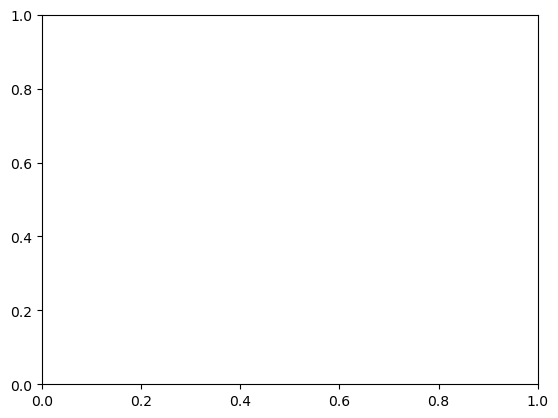

In [7]:
plt.plot(housing_all["year"],housing_all["average_rent"],color = housing_all["room_type"])